In [ ]:
!pip install -qU unsloth trl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.3/317.3 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.7/564.7 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.6/503.6 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.7/247.7 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.5/132.5 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.6/213.6 kB 13.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pylibcudf-cu12 25.6.0 

In [ ]:
# !pip uninstall -y trl

In [ ]:
# !pip cache purge

In [ ]:
import os
import json
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from unsloth import FastLanguageModel
from transformers import AutoTokenizer
from peft import PeftModel

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    balanced_accuracy_score,
    classification_report
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:
BASE_MODEL_NAME = "unsloth/Qwen2-0.5B-Instruct-bnb-4bit"
SFT_ADAPTER_PATH = "/content/o6ai-agent-hr/models/sft_v4_large_balanced_model/checkpoint-676"
GRPO_ADAPTER_PATH = "/content/o6ai-agent-hr/models/grpo_final_model-v1"
EVAL_DATA_PATH = "/content/o6ai-agent-hr/data/eval_data.json"
SAMPLE_INDEX_FOR_QUALITATIVE_ANALYSIS = 42

In [ ]:
print(f"Loading evaluation data from {EVAL_DATA_PATH}...")
eval_df = pd.read_json(EVAL_DATA_PATH)
print(f"Loaded {len(eval_df)} evaluation samples.")

Loading evaluation data from /content/o6ai-agent-hr/data/eval_data.json...
Loaded 104 evaluation samples.


In [ ]:
def create_evaluation_messages(job_skills_str, evaluation_json_str):
    """Creates the prompt with the simplified instruction for the models."""
    candidate_skills_str = ''
    try:
        eval_data = json.loads(evaluation_json_str)
        present_skills = eval_data.get('skills_match', {}).get('present_skills', [])
        candidate_skills_str = ", ".join(present_skills)
    except (json.JSONDecodeError, TypeError):
        pass

    user_content = (
        f"You are an HR expert. Evaluate the candidate's skills against the job requirements.\n\n"
        f"### Job Requirements:\n{job_skills_str}\n\n"
        f"### Candidate Skills:\n{candidate_skills_str}\n\n"
        f"Provide your assessment in a simple JSON format containing only the status and score."
    )
    return [{"role": "user", "content": user_content}]

def parse_model_output(generated_text):
    """Parses the simplified JSON output to extract status and score."""
    try:
        start_index = generated_text.find('{')
        end_index = generated_text.rfind('}')
        if start_index != -1 and end_index != -1:
            data = json.loads(generated_text[start_index:end_index+1])
            raw_status = str(data.get('status', '')).upper()
            # Lenient status parsing to catch variations
            final_status = "SELECTED" if any(kw in raw_status for kw in ["SELECT", "APPROVE", "CONSIDER", "YES"]) else "REJECTED"
            return {
                'predicted_status': final_status,
                'predicted_score': int(data.get('score', 0)),
            }
    except Exception:
        pass
    # Fallback in case of parsing error
    return {'predicted_status': 'REJECTED', 'predicted_score': 0}

def load_model_with_adapter(base_model_name, adapter_path):
    """Loads the base model and attaches a specified LoRA adapter."""
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=base_model_name,
        max_seq_length=2048,
        load_in_4bit=True,
        # The tokenizer is only returned for the first model load
        # as it is the same for both.
    )
    print(f"Loading adapter from {adapter_path}")
    model = PeftModel.from_pretrained(model, adapter_path)
    return model, tokenizer

def generate_predictions(model, tokenizer, df):
    """Generates predictions for each sample in the dataframe."""
    results = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Generating Predictions for {model.peft_config['default'].peft_type}"):
        messages = create_evaluation_messages(row['job_description_skills'], row['evaluation_json'])
        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

        with torch.no_grad():
            output = model.generate(**inputs, max_new_tokens=128, eos_token_id=tokenizer.eos_token_id)

        # Decode only the newly generated tokens
        decoded = tokenizer.decode(output[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
        results.append(parse_model_output(decoded))
    return results

def calculate_metrics(df, preds, model_name="Model"):
    """Calculates and prints a full suite of metrics for a model's predictions."""
    gt_status = df['status'].map(lambda x: 'SELECTED' if x in ['APPROVE', 'CONSIDER', 'STRONGLY_CONSIDER'] else 'REJECTED')
    gt_scores = [json.loads(x).get('overall_score', 0) for x in df['evaluation_json']]

    pred_status = [p['predicted_status'] for p in preds]
    pred_scores = [p['predicted_score'] for p in preds]

    # --- Calculate Metrics ---
    f1 = precision_recall_fscore_support(gt_status, pred_status, average='binary', pos_label='SELECTED', zero_division=0)[2]
    acc = accuracy_score(gt_status, pred_status)
    balanced_acc = balanced_accuracy_score(gt_status, pred_status)
    mae = np.mean(np.abs(np.array(gt_scores) - np.array(pred_scores)))
    rmse = np.sqrt(np.mean((np.array(gt_scores) - np.array(pred_scores)) ** 2))
    conf_matrix = confusion_matrix(gt_status, pred_status, labels=['SELECTED', 'REJECTED'])

    print(f"\n📌 {model_name} Classification Report:")
    print(classification_report(gt_status, pred_status, zero_division=0))

    return {
        "F1-Score": f1,
        "Accuracy": acc,
        "Balanced Accuracy": balanced_acc,
        "MAE": mae,
        "RMSE": rmse,
        "Confusion Matrix": conf_matrix
    }

In [ ]:
print("\n--- Loading and Evaluating SFT Model ---")
sft_model, tokenizer = load_model_with_adapter(BASE_MODEL_NAME, SFT_ADAPTER_PATH)
sft_predictions = generate_predictions(sft_model, tokenizer, eval_df)
sft_metrics = calculate_metrics(eval_df, sft_predictions, "SFT Model")


--- Loading and Evaluating SFT Model ---
==((====))==  Unsloth 2025.9.10: Fast Qwen2 patching. Transformers: 4.56.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/457M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/265 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/367 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loading adapter from /content/o6ai-agent-hr/models/sft_v4_large_balanced_model/checkpoint-676


Generating Predictions for PeftType.LORA:   0%|          | 0/104 [00:00<?, ?it/s]


📌 SFT Model Classification Report:
              precision    recall  f1-score   support

    REJECTED       0.82      0.95      0.88        43
    SELECTED       0.96      0.85      0.90        61

    accuracy                           0.89       104
   macro avg       0.89      0.90      0.89       104
weighted avg       0.90      0.89      0.89       104



In [ ]:
print("\n--- Loading and Evaluating GRPO Model ---")
grpo_model, _ = load_model_with_adapter(BASE_MODEL_NAME, GRPO_ADAPTER_PATH)
grpo_predictions = generate_predictions(grpo_model, tokenizer, eval_df)
grpo_metrics = calculate_metrics(eval_df, grpo_predictions, "GRPO Model")


--- Loading and Evaluating GRPO Model ---
==((====))==  Unsloth 2025.9.10: Fast Qwen2 patching. Transformers: 4.56.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Loading adapter from /content/o6ai-agent-hr/models/grpo_final_model-v1


Generating Predictions for PeftType.LORA:   0%|          | 0/104 [00:00<?, ?it/s]


📌 GRPO Model Classification Report:
              precision    recall  f1-score   support

    REJECTED       0.83      1.00      0.91        43
    SELECTED       1.00      0.85      0.92        61

    accuracy                           0.91       104
   macro avg       0.91      0.93      0.91       104
weighted avg       0.93      0.91      0.91       104



#COMPARATIVE ANALYSIS: Proving GRPO's Superior Reasoning


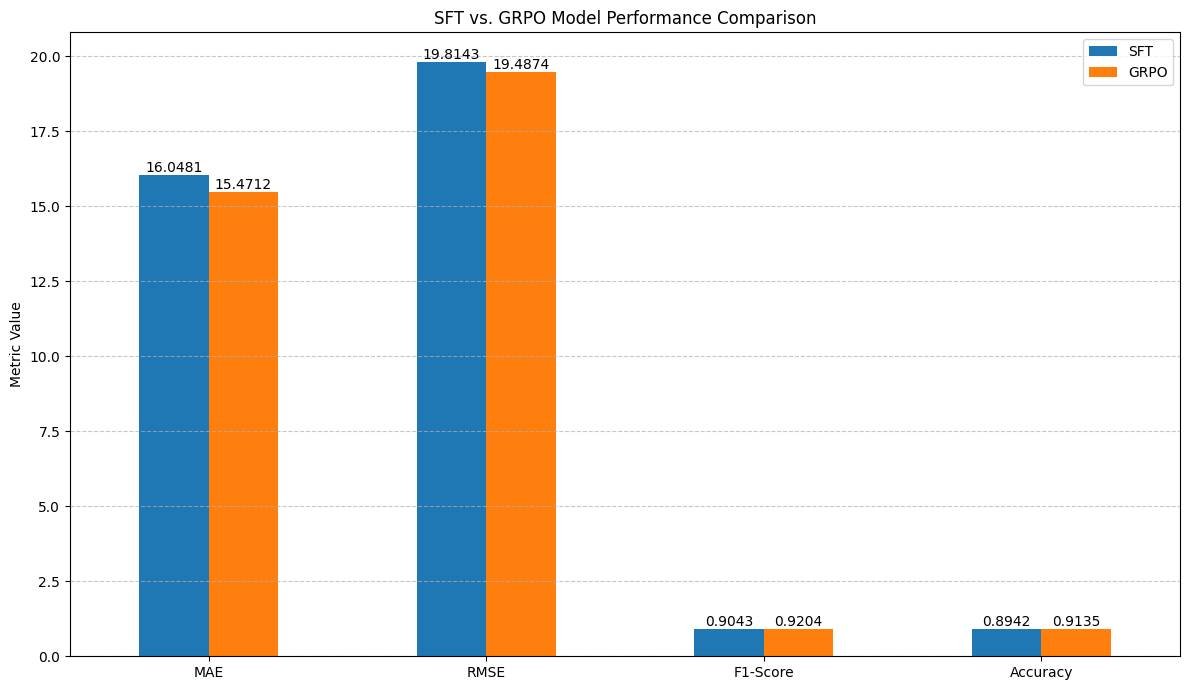

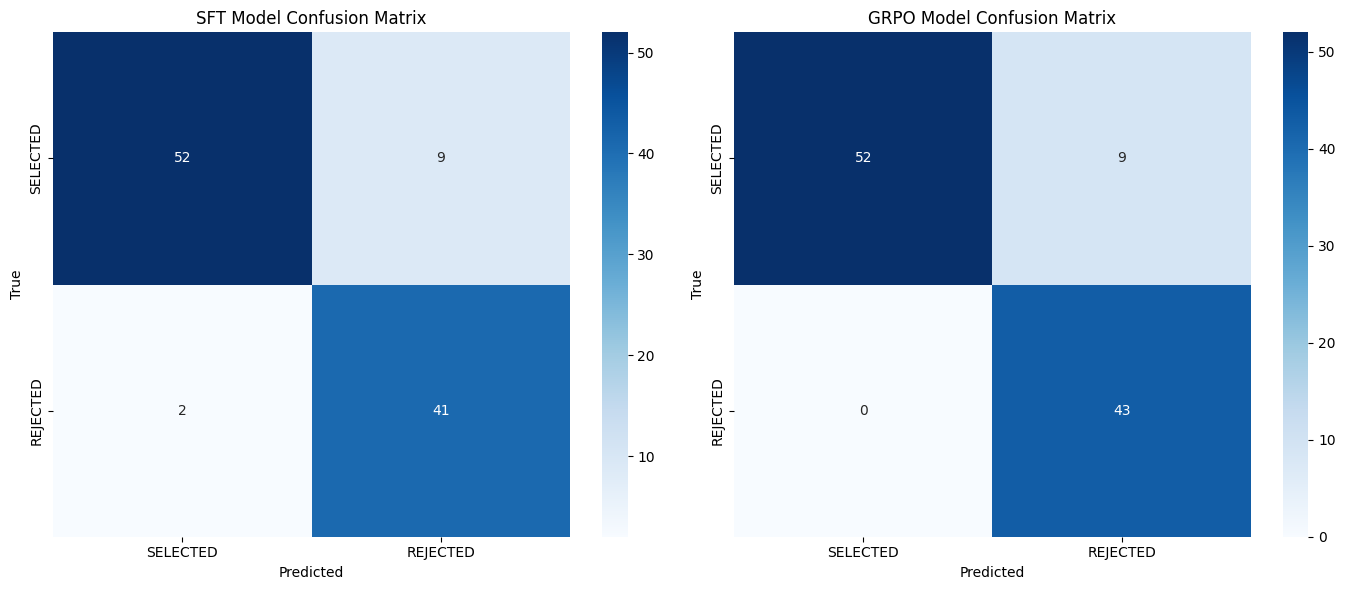

In [ ]:
def plot_comparative_metrics(metrics1, metrics2, label1="SFT", label2="GRPO"):
    """Plots a bar chart comparing key metrics between the two models."""
    # Focus on metrics that show the difference in reasoning (MAE, RMSE)
    keys_to_plot = ["MAE", "RMSE", "F1-Score", "Accuracy"]

    df = pd.DataFrame({
        label1: [metrics1[k] for k in keys_to_plot],
        label2: [metrics2[k] for k in keys_to_plot]
    }, index=keys_to_plot)

    ax = df.plot(kind='bar', figsize=(12, 7), title="SFT vs. GRPO Model Performance Comparison")
    plt.ylabel("Metric Value")
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Add labels to the bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f')

    plt.tight_layout()
    plt.show()

def plot_confusion_matrices(sft_cm, grpo_cm):
    """Plots the confusion matrices for both models side-by-side."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    sns.heatmap(sft_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=["SELECTED", "REJECTED"],
                yticklabels=["SELECTED", "REJECTED"])
    axes[0].set_title("SFT Model Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")

    sns.heatmap(grpo_cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
                xticklabels=["SELECTED", "REJECTED"],
                yticklabels=["SELECTED", "REJECTED"])
    axes[1].set_title("GRPO Model Confusion Matrix")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")

    plt.tight_layout()
    plt.show()

# --- Generate Plots ---
plot_comparative_metrics(sft_metrics, grpo_metrics)
plot_confusion_matrices(sft_metrics["Confusion Matrix"], grpo_metrics["Confusion Matrix"])

# --- Qualitative Analysis: A Case Study ---
def show_qualitative_example(index, df, sft_preds, grpo_preds):
    """Prints a side-by-side comparison for a single candidate."""
    row = df.iloc[index]
    gt = json.loads(row['evaluation_json'])

    candidate_skills_str = ''
    try:
        present_skills = gt.get('skills_match', {}).get('present_skills', [])
        candidate_skills_str = ", ".join(present_skills)
    except Exception: pass

    print("\n" + "="*50)
    print("🧾 QUALITATIVE CASE STUDY")
    print("="*50)
    print(f"Job Description Skills: {row['job_description_skills']}")
    print(f"Candidate's Skills:     {candidate_skills_str}")
    print("-" * 50)
    print(f"Ground Truth Status: {row['status']}")
    print(f"Ground Truth Score:  {gt['overall_score']}\n")

    print("--- SFT Model Prediction ---")
    print(f"Predicted Output: {sft_preds[index]}")
    sft_error = abs(sft_preds[index]['predicted_score'] - gt['overall_score'])
    print(f"Score Error: {sft_error}")


    print("\n--- GRPO Model Prediction ---")
    print(f"Predicted Output: {grpo_preds[index]}")
    grpo_error = abs(grpo_preds[index]['predicted_score'] - gt['overall_score'])
    print(f"Score Error: {grpo_error}")
    print("="*50)



In [ ]:
show_qualitative_example(SAMPLE_INDEX_FOR_QUALITATIVE_ANALYSIS, eval_df, sft_predictions, grpo_predictions)



🧾 Candidate Evaluation Sample:
Job Description Skills: Python, SQL, Spark, ML Ops
Candidate's Skills: Python, SQL, Spark, ML Ops
True Status: APPROVE
True Score: 81

--- SFT Model (v3) Prediction ---
{'predicted_status': 'SELECTED', 'predicted_score': 63}

--- GRPO Model (v6) Prediction ---
{'predicted_status': 'SELECTED', 'predicted_score': 73}
